In [1]:
!pip3 install matplotlib
!pip3 install seaborn
!pip3 install numpy
!pip3 install pandas


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Student Performance Analysis & Prediction

Task 1 — Data Exploration with Pandas

In [2]:
# importing required libraries:
# numpy → numerical operations
# pandas → handling datasets (tables)
# matplotlib → basic plotting
# seaborn → better looking statistical graphs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# setting a clean background style for plots
sns.set_style("whitegrid")

In [3]:
# loading dataset from CSV file into a DataFrame (table format)
df = pd.read_csv("students.csv")
# quick inspection of dataset:
print(df.head())
print(df.shape)
print(df.dtypes)
print(df.describe())

# counting how many students passed (1) and failed (0)
print(df['passed'].value_counts())


      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  
(15, 9)
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object
            math    science    english    history         pe  attendance_pct  \
count  15.000000  

In [4]:
# list of all subject columns for easier reuse
subject_cols = ['math','science','english','history','pe']

# calculating average marks of subjects for students who passed and those who failed
print(df[df['passed']==1][subject_cols].mean())
print(df[df['passed']==0][subject_cols].mean())

# calculating overall average score for each student across all subjects
# axis=1 → row-wise operation
df['overall_avg'] = df[subject_cols].mean(axis=1)
# finding the student with highest average score
# idxmax() → gives index of highest value
# then we use that index to get the student's name
print(df.loc[df['overall_avg'].idxmax()]['name'])

math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64
math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64
Diana


In [5]:
#the above code is as mentioned in task 2, to run this before continuing task 2.

Task 2 — Data Visualization with Matplotlib

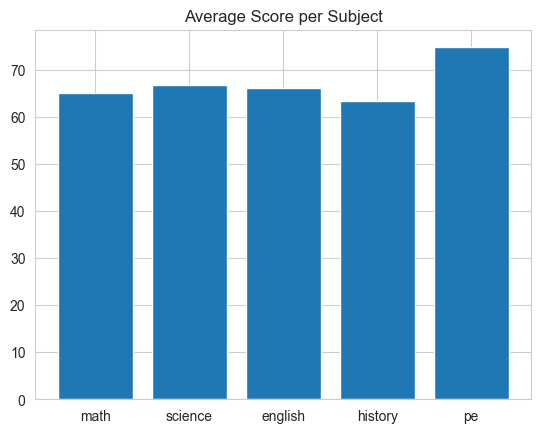

In [6]:
# creating another column (duplicate idea, but maybe for plotting clarity)
df['avg_score'] = df[subject_cols].mean(axis=1)

# bar chart
# showing average score of each subject across all students
plt.bar(subject_cols, df[subject_cols].mean())
plt.title("Average Score per Subject") # adding title for clarity
plt.savefig("plot1.png") # saving the plot as an image file
plt.show() # displaying the plot

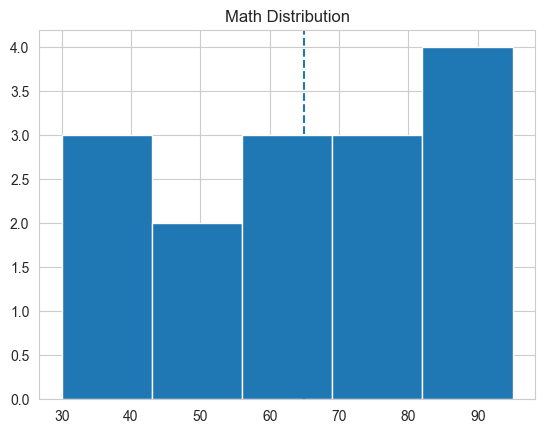

In [7]:
df['avg_score'] = df[subject_cols].mean(axis=1) # creating another column (duplicate idea, but maybe for plotting clarity)

# histogram
# showing distribution of math marks
plt.hist(df['math'], bins=5)  # dividing data into 5 groups (bins)
plt.axvline(df['math'].mean(), linestyle='dashed') # drawing a vertical line showing average math score
plt.title("Math Distribution")
plt.savefig("plot2.png")
plt.show()

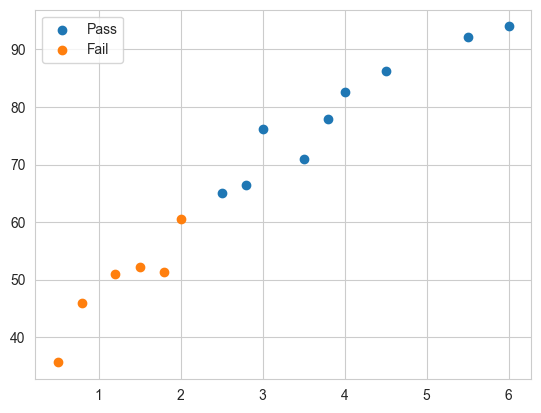

In [8]:
df['avg_score'] = df[subject_cols].mean(axis=1) # creating another column (duplicate idea, but maybe for plotting clarity)

# scatter
# plotting study hours vs average score for students who passed and those who failed
plt.scatter(df[df['passed']==1]['study_hours_per_day'],
            df[df['passed']==1]['avg_score'], label='Pass')

plt.scatter(df[df['passed']==0]['study_hours_per_day'],
            df[df['passed']==0]['avg_score'], label='Fail')
# showing legend to differentiate pass/fail
plt.legend()
plt.savefig("plot3.png") # saving the plot
plt.show() # displaying final scatter plot


Task 3 — Exception Handling

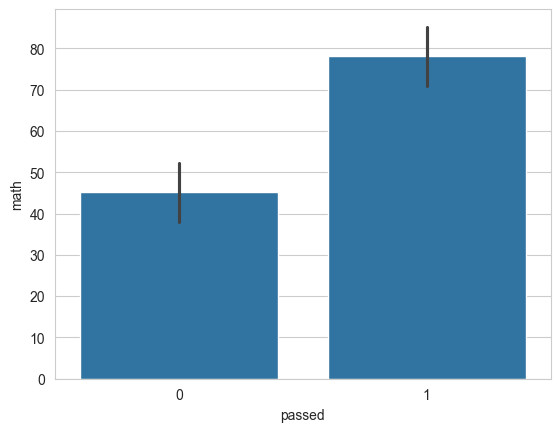

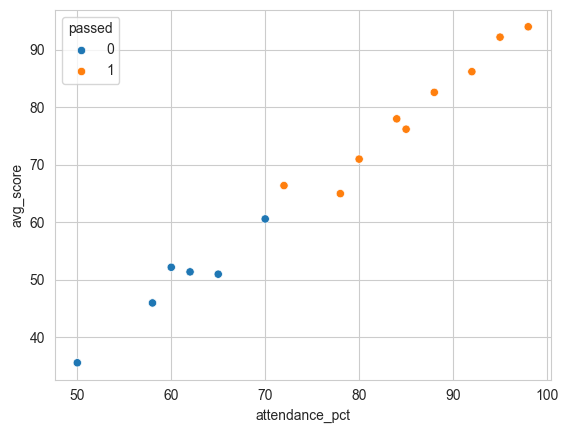

In [9]:
import seaborn as sns
# this plot shows how math scores differ between students who passed (1) and failed (0)
# x-axis → pass/fail category
# y-axis → math marks
# seaborn automatically calculates average math score for each group
sns.barplot(data=df, x='passed', y='math')
plt.show()

sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')
plt.show() # displaying the graph


Task 4 — Logging to File 

In [10]:
# importing required ML tools from sklearn
from sklearn.model_selection import train_test_split  # to split dataset
from sklearn.preprocessing import StandardScaler # to scale data
from sklearn.linear_model import LogisticRegression # classification model
# FEATURE SELECTION 
# X → input features (independent variables)
# these are the factors used to predict result
X = df[['math','science','english','history','pe','attendance_pct','study_hours_per_day']]
y = df['passed'] # y → target/output (dependent variable)
# this is what we are trying to predict (pass or fail)

# TRAIN-TEST SPLIT
# splitting dataset into training and testing parts
# 80% → training data (model learns from this)
# 20% → testing data (used to check performance)
# random_state ensures same split every time for consistency
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# FEATURE SCALING
# scaling ensures all features are on similar scale
# important for models like logistic regression
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MODEL TRAINING - creating logistic regression model, used for binary classification (pass/fail)
model = LogisticRegression()
model.fit(X_train,y_train) # training the model using training data

# MODEL EVALUATION
print("Train Accuracy:", model.score(X_train,y_train)) # checking how well model performs on training data
print("Test Accuracy:", model.score(X_test,y_test)) # checking performance on unseen test data (more important)


Train Accuracy: 1.0
Test Accuracy: 1.0
